In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [89]:
df=pd.read_pickle(r'C:\Users\Lenovo\Desktop\Div Academy\Home-Credit-Risk-Management\Datas\cleaned_data.pkl')


In [90]:
print(f"Shape       : {df.shape}")
print(f"Target dist :\n{df['target'].value_counts(normalize=True).round(3)}")
print(f"\nDtypes:\n{df.dtypes.value_counts()}")
print(f"\nNull number : {df.isnull().sum().sum()}")
df.head(3)


Shape       : (307511, 73)
Target dist :
target
0    0.919
1    0.081
Name: proportion, dtype: float64

Dtypes:
float64    55
object     12
int64       6
Name: count, dtype: int64

Null number : 1008921


,ext_source_mean,credit_to_goods,ext_source_1,amt_annuity,instalment_utilization_x,amt_credit,ext_source_3,days_id_publish,ext_source_2,max_payment_delay,...,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,occupation_type,weekday_appr_process_start,organization_type,target,age
0,0.161787,1.158394,0.083037,24700.5,0.600000,406597.5,0.139376,-2120,0.262949,-12.0,...,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,1,25
1,0.466757,1.145198,0.311267,35698.5,0.520900,1293502.5,0.535276,-291,0.622246,-1.0,...,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,0,45
2,0.642739,0.999993,0.505998,6750.0,0.473684,135000.0,0.729567,-2531,0.555912,-3.0,...,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,0,52


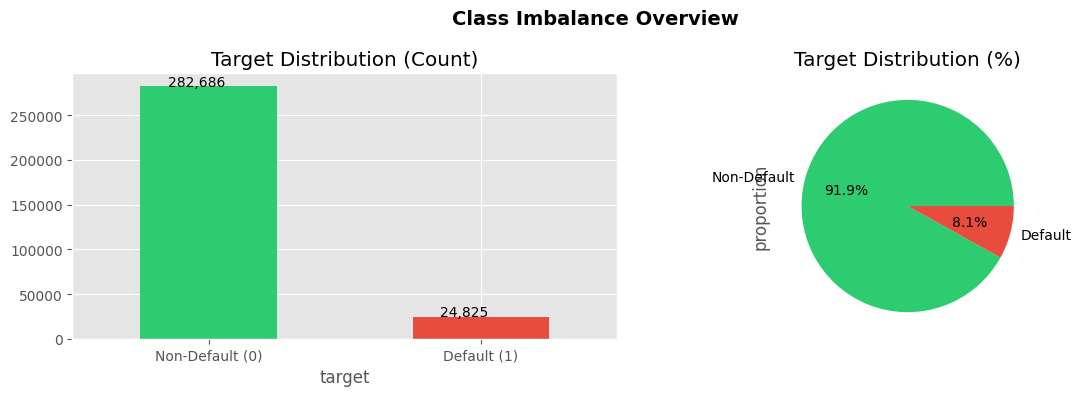

In [91]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['target'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Target Distribution (Count)')
axes[0].set_xticklabels(['Non-Default (0)', 'Default (1)'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + 0.1, p.get_height() + 500))

df['target'].value_counts(normalize=True).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'], labels=['Non-Default', 'Default']
)
axes[1].set_title('Target Distribution (%)')
plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Dataset is highly imbalanced (91.9% and 8.1%). Evaluation metrics should focus on AUC-ROC rather than accuracy

In [92]:
df.head()

,ext_source_mean,credit_to_goods,ext_source_1,amt_annuity,instalment_utilization_x,amt_credit,ext_source_3,days_id_publish,ext_source_2,max_payment_delay,...,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,occupation_type,weekday_appr_process_start,organization_type,target,age
0,0.161787,1.158394,0.083037,24700.5,0.600000,406597.5,0.139376,-2120,0.262949,-12.0,...,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,1,25
1,0.466757,1.145198,0.311267,35698.5,0.520900,1293502.5,0.535276,-291,0.622246,-1.0,...,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,0,45
2,0.642739,0.999993,0.505998,6750.0,0.473684,135000.0,0.729567,-2531,0.555912,-3.0,...,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,0,52
3,0.650442,1.052799,0.505998,29686.5,0.665385,312682.5,0.535276,-2437,0.650442,-1.0,...,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,0,52
4,0.322738,0.999998,0.505998,21865.5,0.549165,513000.0,0.535276,-3458,0.322738,12.0,...,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,0,54


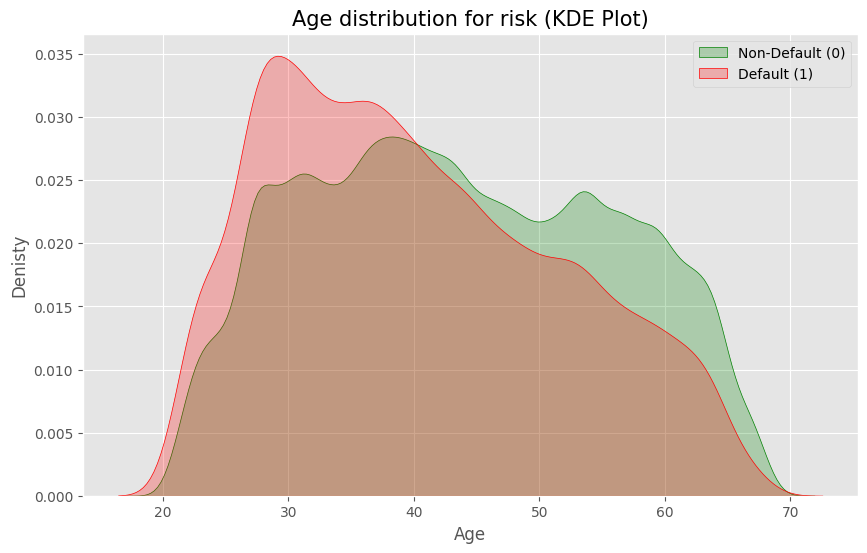

In [93]:
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))

sns.kdeplot(df.loc[df['target'] == 0, 'age'], label='Non-Default (0)', fill=True, color='green')
sns.kdeplot(df.loc[df['target'] == 1, 'age'], label='Default (1)', fill=True, color='red')

plt.title('Age distribution for risk (KDE Plot)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Denisty', fontsize=12)
plt.legend()
plt.show()

### Feature Engineering: Age Binning
Based on the **KDE Plot** analysis, we observe that the risk of credit default is distributed unevenly across different age categories. To capture this non-linear relationship and improve model interpretability, I am creating a new feature called `age_group` through binning.

**The data indicates three distinct risk profiles:**
* **High Risk (Ages 20-27):** This group shows the highest density of default cases.
* **Medium Risk (Ages 30-45):** A transitional phase where the default rate begins to stabilize.
* **Low Risk (Ages 45+):** This category demonstrates the highest repayment reliability.

By discretizing the `age` variable, I aim to help the model better distinguish between these risk tiers and reduce the impact of minor fluctuations (noise) within individual ages.

In [94]:
def get_age_group(age):
    if age < 30:
        return 'Young_High_Risk'
    elif 30 <= age < 45:
        return 'Middle_Age_Medium_Risk'
    else:
        return 'Senior_Low_Risk'

df['age_group'] = df['age'].apply(get_age_group)

print(df.groupby('age_group')['target'].mean())

age_group
Middle_Age_Medium_Risk    0.090046
Senior_Low_Risk           0.061457
Young_High_Risk           0.114556
Name: target, dtype: float64


also we can see the results here

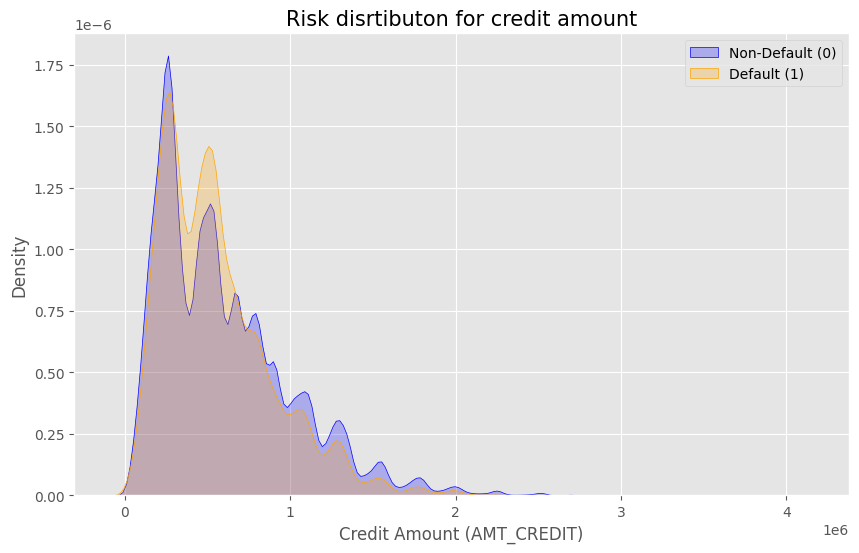

In [95]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df.loc[df['target'] == 0, 'amt_credit'], label='Non-Default (0)', fill=True, color='blue')
sns.kdeplot(df.loc[df['target'] == 1, 'amt_credit'], label='Default (1)', fill=True, color='orange')

plt.title('Risk disrtibuton for credit amount', fontsize=15)
plt.xlabel('Credit Amount (AMT_CREDIT)', fontsize=12)
plt.legend()
plt.show()

Low Range (0 - 500,000): This interval shows the highest concentration of successful repayments. It likely represents standardized credit products (e.g., consumer loans) where borrowers find the installments more manageable.

High-Risk Zone (500,000 - 1,000,000): This is the most critical interval. The default density peaks here, suggesting that borrowers in this range may be overextending their financial capacity, or the bank's screening process for mid-tier loans is less stringent.

Premium Range (> 1,000,000): Interestingly, for very high credit amounts, the number of people who repay exceeds those who default. This indicates that the bank performs a more rigorous and attentive credit analysis before approving large-scale loans, ensuring that only high-net-worth or highly reliable clients qualify.

In [96]:
bins = [0, 500000, 1000000, df['amt_credit'].max()]
labels = ['Small_Loan_Safe', 'Mid_Range_High_Risk', 'Premium_High_Amount']

df['credit_segment'] = pd.cut(df['amt_credit'], bins=bins, labels=labels)

print(df.groupby('credit_segment')['target'].mean())

credit_segment
Small_Loan_Safe        0.084409
Mid_Range_High_Risk    0.085847
Premium_High_Amount    0.058658
Name: target, dtype: float64


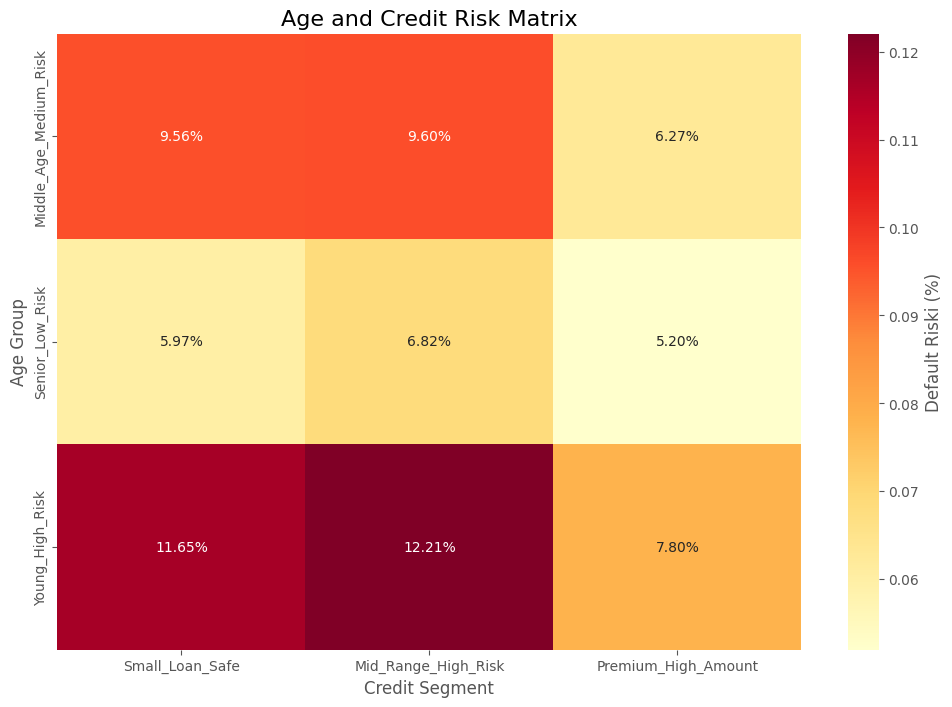

In [97]:
risk_matrix = df.pivot_table(index='age_group', 
                             columns='credit_segment', 
                             values='target', 
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(risk_matrix, annot=True, cmap='YlOrRd', fmt='.2%', cbar_kws={'label': 'Default Riski (%)'})

plt.title('Age and Credit Risk Matrix', fontsize=16)
plt.xlabel('Credit Segment', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.show()

### Key Takeaway from the Risk Matrix (Simplified Analysis)

By looking at the heatmap, I have discovered a very important "rule" in this dataset: **Age is a stronger predictor of risk than the loan amount.**

Imagine we compare two types of customers:
1. **The Young "VIP":** A young person (under 28) who applies for a very large, well-vetted "Premium" loan. Their risk is **7.80%**.
2. **The Senior "Standard":** An older person (over 45) who applies for a medium-sized loan. Their risk is only **6.82%**.

Even though the young person is getting a "Premium" loan (which usually means the bank checked them more strictly), they are **still more likely to default** than an older person with a regular loan.

**Conclusion:**
In this project, a person's age tells us more about their reliability than the amount of money they are asking for. This is why the `age_group` feature I created is so valuable—it captures a "human factor" that the loan amount alone cannot explain.

In [98]:
ext_data_corr = df[['target', 'ext_source_1', 'ext_source_2', 'ext_source_3']].corr()
print(ext_data_corr['target'].sort_values())

ext_source_2   -0.160295
ext_source_3   -0.155892
ext_source_1   -0.098887
target          1.000000
Name: target, dtype: float64


It shows that our external source 2 and 3 give us strong infomation about this customers results in other banks, but we will find mean of 3 of them for each customer to solve NaN and missing value problems and to give more stable result

In [99]:
df['EXT_SOURCES_MEAN'] = df[['ext_source_1', 'ext_source_2', 'ext_source_3']].mean(axis=1)

In [100]:
df[['target', 'EXT_SOURCES_MEAN']].corr()

,target,EXT_SOURCES_MEAN
target,1.00000,-0.22084
EXT_SOURCES_MEAN,-0.22084,1.00000


so increased  strength of correlation 37%

In [101]:

# creaiting anomaly column to explain to model that ,they are not unemplooyeed,it is special customer
df['DAYS_EMPLOYED_ANOM'] = df["days_employed"] == 365243

# replacing anomaly values with NaN
df['days_employed'].replace({365243: np.nan}, inplace=True)

df['days_employed'] = df['days_employed'].abs()


In [102]:
missing_values = df.isnull().mean() * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values.head(20)) # Ən çox boş olan ilk 20 sütun

occupation_type                 31.345545
days_employed                   18.007161
organization_type               18.007161
debt_ratio__x                   14.646305
sk_id_bureau_count_x            14.314935
type_consumer credit_sum_x      14.314935
type_mortgage_sum_x             14.314935
amt_credit_sum_debt_sum_x       14.314935
is_credit_active_sum_x          14.314935
amt_credit_sum_sum_x            14.314935
amt_credit_sum_overdue_sum_x    14.314935
instalment_utilization_x         5.875237
avg_instalment_x                 5.875237
avg_dpd_def_x                    5.875237
pos_contract_count_x             5.875237
months_balance_max_x             5.875237
activity_span_x                  5.875237
max_instalment_x                 5.875237
months_balance_min_x             5.875237
down_payment_ratio_x             5.424521
dtype: float64


In [103]:
df['DAYS_EMPLOYED_ANOM']=df['DAYS_EMPLOYED_ANOM'].astype(int)

In [104]:
df.drop(columns='employment_years',inplace=True)


In [105]:
df['years_employed']=df['days_employed'] / 365



In [106]:
df.drop(columns='days_employed',inplace=True)

In [107]:
# Bureau numeric columns
bureau_cols = [
    'sk_id_bureau_count_x', 
    'amt_credit_sum_sum_x', 
    'is_credit_active_sum_x', 
    'amt_credit_sum_debt_sum_x', 
    'amt_credit_sum_overdue_sum_x',
    'type_consumer credit_sum_x',
    'type_mortgage_sum_x'
]

df[bureau_cols] = df[bureau_cols].fillna(0)
# It means ,this customer don't have bureau history

In [108]:
# we have 31% NaN in occupaiton_type column,and we can't fill them with 0,so we can fill them as 'Unknown'
df['occupation_type'] = df['occupation_type'].fillna('Unknown')

In [109]:
df.drop(columns='EXT_SOURCES_MEAN',inplace=True)
# we deleted given EXT_SOURCES_MEAN column because we created it ourselves

Work experience distribution

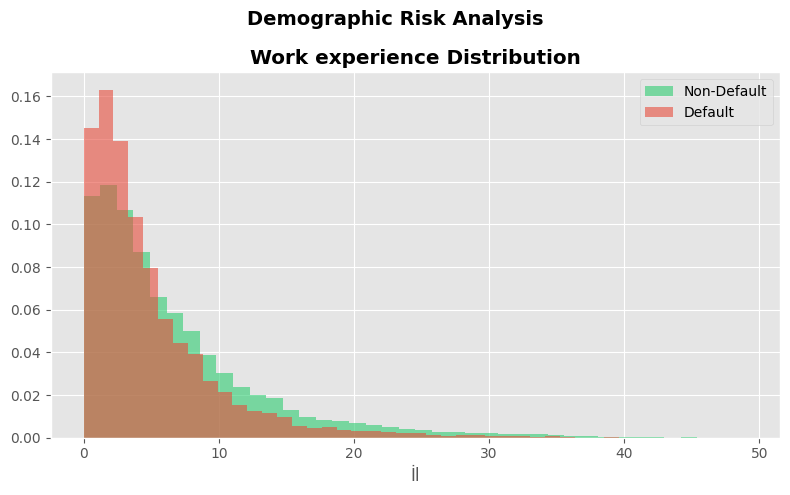

In [110]:
fig, ax = plt.subplots(figsize=(8, 5))

if 'years_employed' in df.columns:
    df_plot = df[df['years_employed'] < 50]
    
    df_plot[df_plot['target']==0]['years_employed'].hist(
        bins=40, ax=ax, alpha=0.6, color='#2ecc71',
        label='Non-Default', density=True)
    
    df_plot[df_plot['target']==1]['years_employed'].hist(
        bins=40, ax=ax, alpha=0.6, color='#e74c3c',
        label='Default', density=True)
    
    # 3. ax obyektinin metodlarını istifadə edirik
    ax.set_title('Work experience Distribution', fontweight='bold')
    ax.set_xlabel('İl')
    ax.legend()

plt.suptitle('Demographic Risk Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

High-Risk Zone: Customers with 0–5 years of work experience show a significantly higher density of 'Default' cases. This suggests that individuals at the early stages of their careers may have lower financial stability.

Stability Zone: As work experience exceeds 10+ years, the proportion of 'Default' cases drops noticeably, while 'Non-Default' cases remain dominant. This indicates that long-term employment is a strong proxy for reliability.

Strategic Insight: The years_employed feature exhibits high predictive power regarding creditworthiness. It should be prioritized as a key variable in the final credit scoring model due to its high Feature Importance.

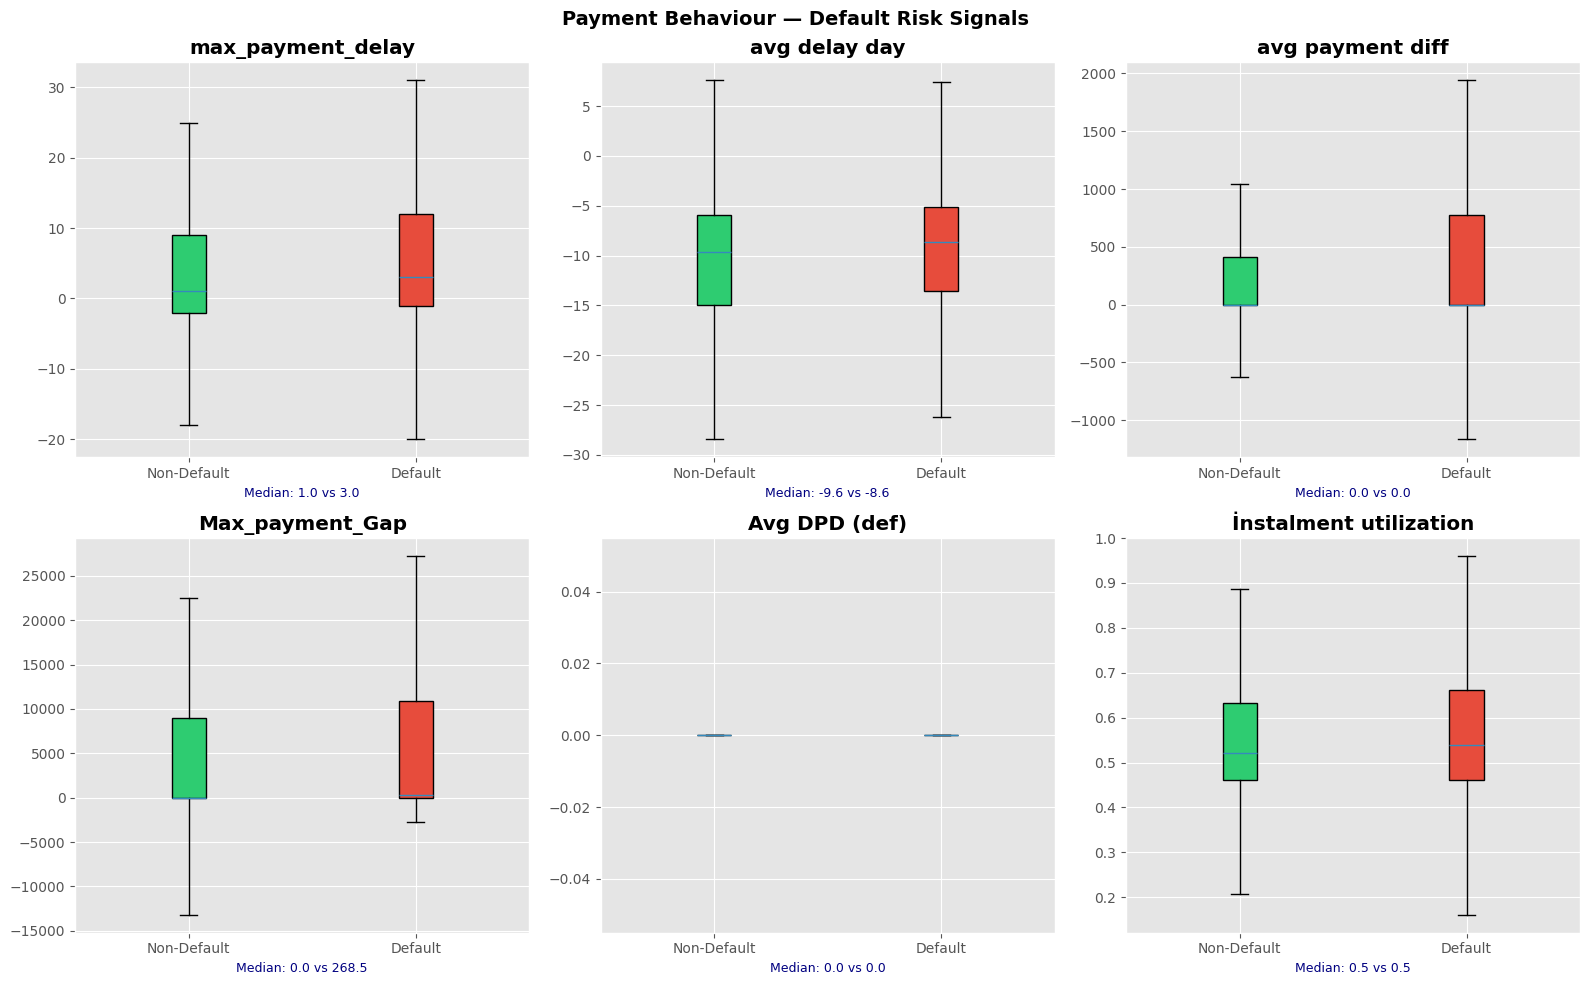

In [111]:
payment_cols = {
    'max_payment_delay' : 'max_payment_delay',
    'avg_payment_delay' : 'avg delay day',
    'avg_payment_gap'   : 'avg payment diff',
    'max_payment_gap'   : 'Max_payment_Gap',
    'avg_dpd_def_x'     : 'Avg DPD (def)',
    'instalment_utilization_x': 'İnstalment utilization'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (col, label) in zip(axes.flatten(), payment_cols.items()):
    if col not in df.columns:
        continue
    data_0 = df[df['target']==0][col].dropna()
    data_1 = df[df['target']==1][col].dropna()

    bp = ax.boxplot([data_0, data_1],
                    patch_artist=True,
                    labels=['Non-Default', 'Default'],
                    showfliers=False)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(label, fontweight='bold')

    m0 = data_0.median()
    m1 = data_1.median()
    ax.set_xlabel(f'Median: {m0:.1f} vs {m1:.1f}', fontsize=9, color='navy')

plt.suptitle('Payment Behaviour — Default Risk Signals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Key Discriminators: max_payment_delay and max_payment_gap are the most significant indicators. Higher values in these metrics strongly correlate with a higher probability of default, suggesting that inconsistent payment behavior is a primary risk factor.

Financial Strain: The instalment_utilization metric shows higher dispersion for default cases, indicating that customers with higher payment-to-income ratios are more prone to default.

Redundant Features: Metrics such as Avg DPD (def) and avg_payment_gap show no significant difference between the two groups, implying low predictive value for the risk model.

Strategic Recommendation: Focus on max_payment_delay and max_payment_gap as primary features in the credit scoring model, as they provide the most actionable intelligence for identifying high-risk applicants.

In [112]:
df.drop(columns=['avg_dpd_def_x','avg_payment_gap'],inplace=True)
# In my graph analysing ,I see that ,that columns are not important for our model prediction 

Credit applying behaviours

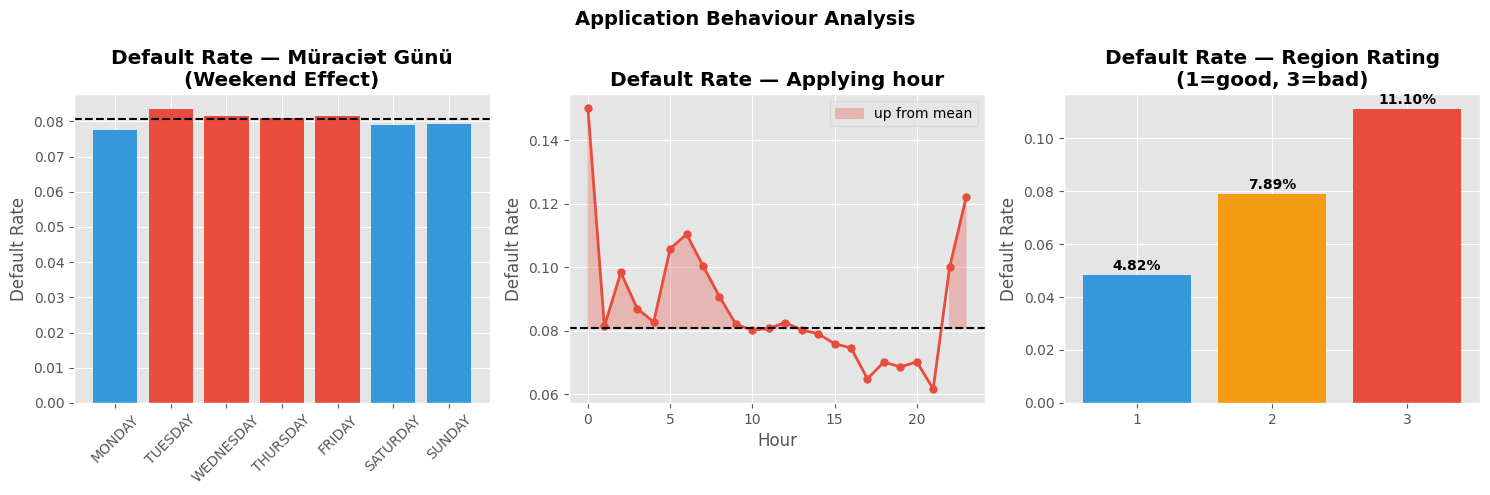

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

if 'weekday_appr_process_start' in df.columns:
    day_order = ['MONDAY','TUESDAY','WEDNESDAY','THURSDAY',
                 'FRIDAY','SATURDAY','SUNDAY']
    day_rate = df.groupby('weekday_appr_process_start')['target'].mean()
    day_rate = day_rate.reindex(
        [d for d in day_order if d in day_rate.index])

    bars = axes[0].bar(day_rate.index, day_rate.values,
                       color=['#e74c3c' if v > df['target'].mean()
                              else '#3498db' for v in day_rate.values])
    axes[0].axhline(y=df['target'].mean(),
                    color='black', linestyle='--')
    axes[0].set_title('Default Rate — Müraciət Günü\n(Weekend Effect)',
                      fontweight='bold')
    axes[0].set_ylabel('Default Rate')
    axes[0].tick_params(axis='x', rotation=45)

if 'hour_appr_process_start' in df.columns:
    hour_rate = df.groupby('hour_appr_process_start')['target'].mean()
    axes[1].plot(hour_rate.index, hour_rate.values,
                 color='#e74c3c', linewidth=2, marker='o', markersize=5)
    axes[1].axhline(y=df['target'].mean(),
                    color='black', linestyle='--')
    axes[1].fill_between(hour_rate.index, hour_rate.values,
                         df['target'].mean(),
                         where=hour_rate.values > df['target'].mean(),
                         alpha=0.3, color='#e74c3c', label='up from mean')
    axes[1].set_title('Default Rate — Applying hour',
                      fontweight='bold')
    axes[1].set_xlabel('Hour')
    axes[1].set_ylabel('Default Rate')
    axes[1].legend()

# Region rating
if 'region_rating_client' in df.columns:
    reg_rate = df.groupby('region_rating_client')['target'].mean()
    axes[2].bar(reg_rate.index.astype(str), reg_rate.values,
                color=['#3498db','#f39c12','#e74c3c'])
    axes[2].set_title('Default Rate — Region Rating\n(1=good, 3=bad)',
                      fontweight='bold')
    axes[2].set_ylabel('Default Rate')
    for bar, val in zip(axes[2].patches, reg_rate.values):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{val:.2%}', ha='center', fontweight='bold')

plt.suptitle('Application Behaviour Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Temporal Anomalies: Applications submitted during late-night hours (00:00 - 05:00) show a significantly higher default rate compared to the daytime average. This behavior often suggests urgent, high-risk borrowing needs.

Socio-Economic Link: The Region Rating is a powerful discriminator. There is a clear positive correlation between a lower regional rating (3 = bad) and higher default risk, reinforcing the importance of geographical socio-economic factors in credit scoring.

Strategic Takeaway: The model should assign higher weights to time-of-day and regional data, as these behavioral features act as strong proxies for a customer's financial stability.

Correlation Heatmap

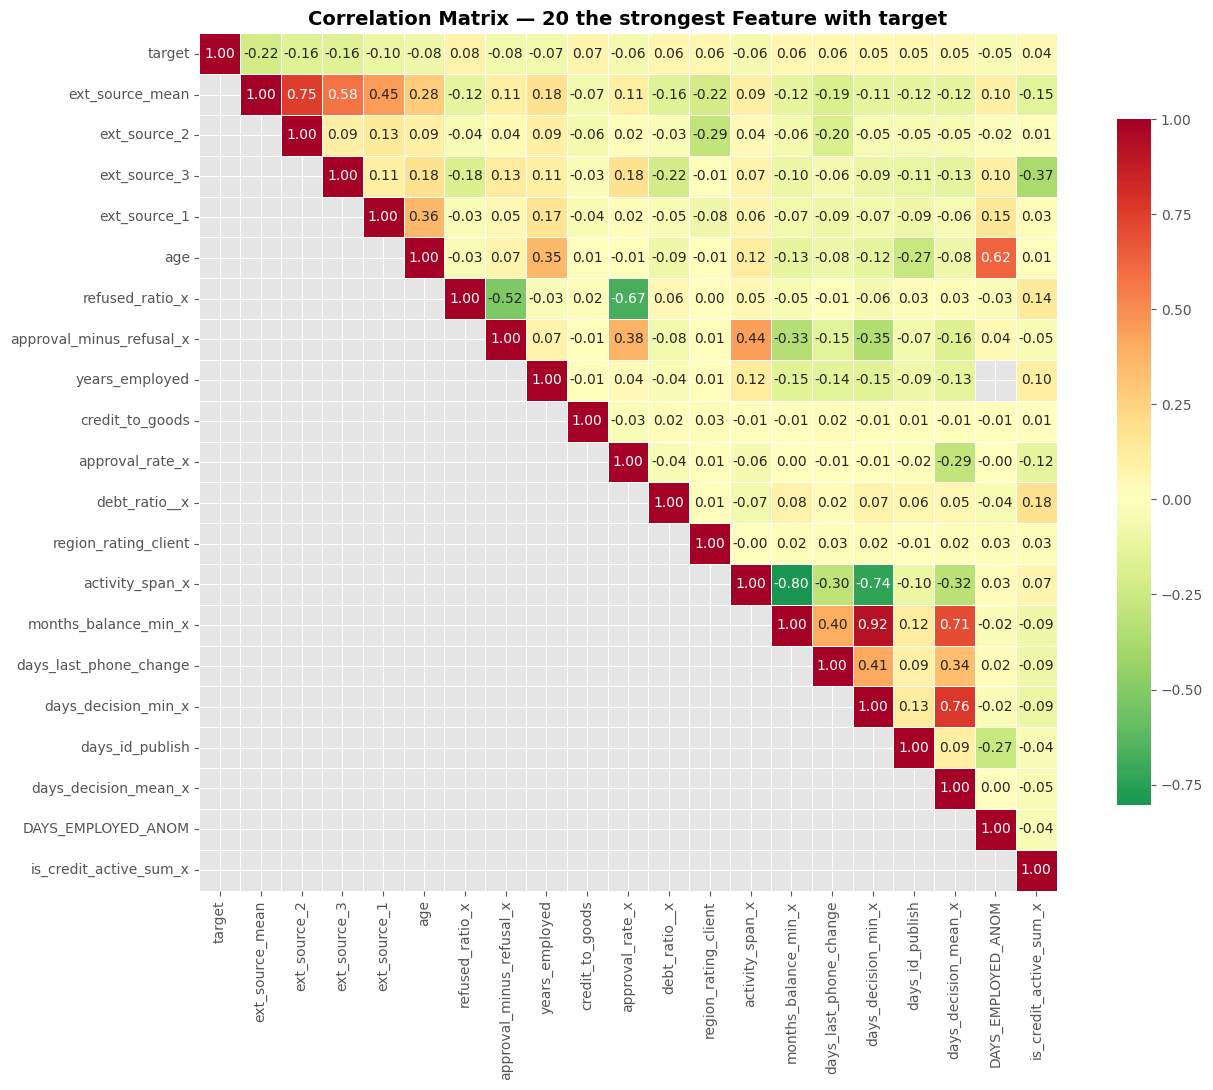

In [114]:
# Target ilə ən çox korrelyasiyalı top 20 numeric feature
num_df   = df.select_dtypes(include=np.number)
top_corr = (num_df.corr()['target']
            .abs()
            .sort_values(ascending=False)
            .head(21)
            .index.tolist())

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones((len(top_corr), len(top_corr))), k=1)
sns.heatmap(
    num_df[top_corr].corr(),
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    mask=mask.T,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix — 20 the strongest Feature with target',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

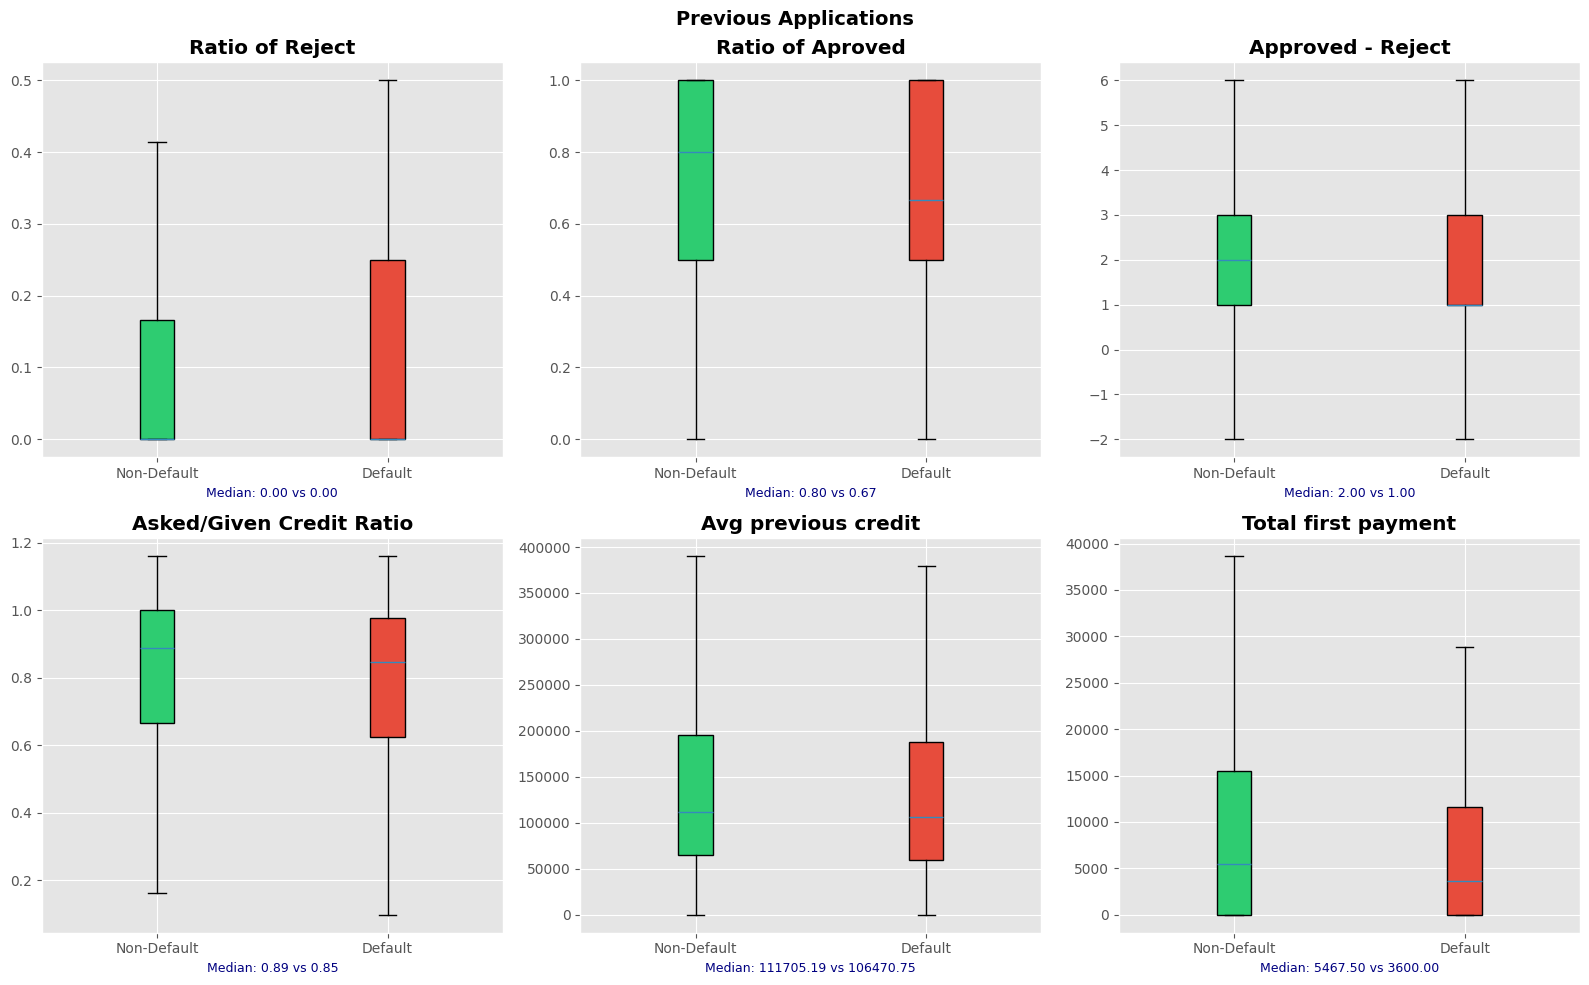

In [115]:
prev_cols = {
    'refused_ratio_x'       : 'Ratio of Reject',
    'approval_rate_x'       : 'Ratio of Aproved',
    'approval_minus_refusal_x': 'Approved - Reject',
    'asked_credit_ratio_mean_x': 'Asked/Given Credit Ratio',
    'avg_credit_x'          : 'Avg previous credit',
    'total_down_payment_x'  : 'Total first payment'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (col, label) in zip(axes.flatten(), prev_cols.items()):
    if col not in df.columns:
        continue
    d0 = df[df['target']==0][col].dropna()
    d1 = df[df['target']==1][col].dropna()
    p95 = df[col].quantile(0.95)
    d0, d1 = d0[d0 <= p95], d1[d1 <= p95]

    bp = ax.boxplot([d0, d1], patch_artist=True,
                    labels=['Non-Default', 'Default'],
                    showfliers=False)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(
        f'Median: {d0.median():.2f} vs {d1.median():.2f}',
        fontsize=9, color='navy')

plt.suptitle('Previous Applications',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Past Approval Success: A higher Approval Rate in the past (Median 0.80 for Non-Default vs 0.67 for Default) is one of the strongest indicators of future reliability. Clients whose previous applications were frequently rejected by banks remain high-risk.

Financial Commitment: The Total Down Payment metric shows that reliable customers tend to make higher initial payments (Median ~5.5k vs ~3.6k). This suggests a higher level of financial equity and commitment to the loan.

Rejection Sensitivity: While the medians for rejection rates are low for both, the wider distribution in the Default group indicates that a history of multiple rejections is a significant "red flag."

In [116]:
print("=" * 65)
print("KEY FINDINGS")
print("=" * 65)

findings = []
for col in df.select_dtypes(include=np.number).columns:
    if col == 'target':
        continue
    m0 = df[df['target']==0][col].mean()
    m1 = df[df['target']==1][col].mean()
    if m0 != 0:
        diff_pct = abs(m0 - m1) / abs(m0) * 100
        findings.append({
            'feature'       : col,
            'mean_nondefault': round(m0, 3),
            'mean_default'  : round(m1, 3),
            'diff_%'        : round(diff_pct, 1)
        })

findings_df = (pd.DataFrame(findings)
               .sort_values('diff_%', ascending=False)
               .head(15))
print(findings_df.to_string(index=False))

KEY FINDINGS
                     feature  mean_nondefault  mean_default  diff_%
amt_credit_sum_overdue_sum_x          137.058       806.571   488.5
             refused_ratio_x            0.107         0.159    49.0
         type_mortgage_sum_x            0.052         0.031    40.1
          DAYS_EMPLOYED_ANOM            0.185         0.120    35.0
               elevators_avg            0.038         0.025    34.7
    approval_minus_refusal_x            2.256         1.585    29.7
              years_employed            6.680         4.972    25.6
        total_down_payment_x        15506.903     11598.721    25.2
             ext_source_mean            0.519         0.397    23.5
                ext_source_2            0.524         0.411    21.5
        down_payment_ratio_x            0.048         0.038    21.2
                ext_source_3            0.524         0.424    19.1
      days_last_phone_change         -976.388      -808.797    17.2
      is_credit_active_sum_x       

In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder